# Experiments
This file contains the necesary experiments to create a model for ***recognizing the sentiment of comments, differentiating between 'hatefull' and 'not hatefull' comments***.

### Dataset analysis
First, we decided to take a closer look at the dataset we received for this task. As we can see, the data contains comments that should be classified as hateful or not hateful. Before we move to model building, it is important to understand what kind of texts we are working with and how should we handle them.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

train_dataframe = pd.read_csv("../hate_train.csv")

text_column = train_dataframe.columns[0]   
label_column = train_dataframe.columns[1]  

print(f"Amount of samples in total: {len(train_dataframe)}")
print(f"Data columns: {train_dataframe.columns.tolist()}")

Amount of samples in total: 10041
Data columns: ['sentence', 'label']


The dataset has **10,041 samples** and two columns: sentence and label. The texts are rather short and look like social media comments.

#### Example samples from the dataset provided.

In [55]:
for klasa in sorted(train_dataframe[label_column].unique()):
    print(f"\nClass label {klasa} ")
    example_samples = train_dataframe[train_dataframe[label_column] == klasa][text_column].head(3)
    for tekst in example_samples:
        print(f"  - {tekst[:200]}")


Class label 0 
  - Dla mnie faworytem do tytułu będzie Cracovia. Zobaczymy, czy typ się sprawdzi.
  - @anonymized_account @anonymized_account Brawo ty Daria kibic ma być na dobre i złe
  - @anonymized_account @anonymized_account Super, polski premier składa kwiaty na grobach kolaborantów. Ale doczekaliśmy czasów.

Class label 1 
  - @anonymized_account @anonymized_account @anonymized_account Gdzie jest @anonymized_account . Brudziński jesteś kłamcą i marnym kutasem @anonymized_account
  - @anonymized_account @anonymized_account No to Skończmy kurwa z tym wersalem w j...ej szczujni
  - #Woronicza 17 poseł Halicki oburzony za Bolka.Naprawdè taki tępy czy tylko udaje idiotę?


Class **0** contains more **neutral or regular** statements, while class **1** contains clearly **offensive or hateful** language. 
- `not_hatefull`: label **0**
- `hatefull`: label **1**

As we can also see, the dataset contains **Polish comments**, we need a model that handles Polish text well. We should also keep the original casing, because the text is cased and capitalization may carry useful information.

### The distribution of classes

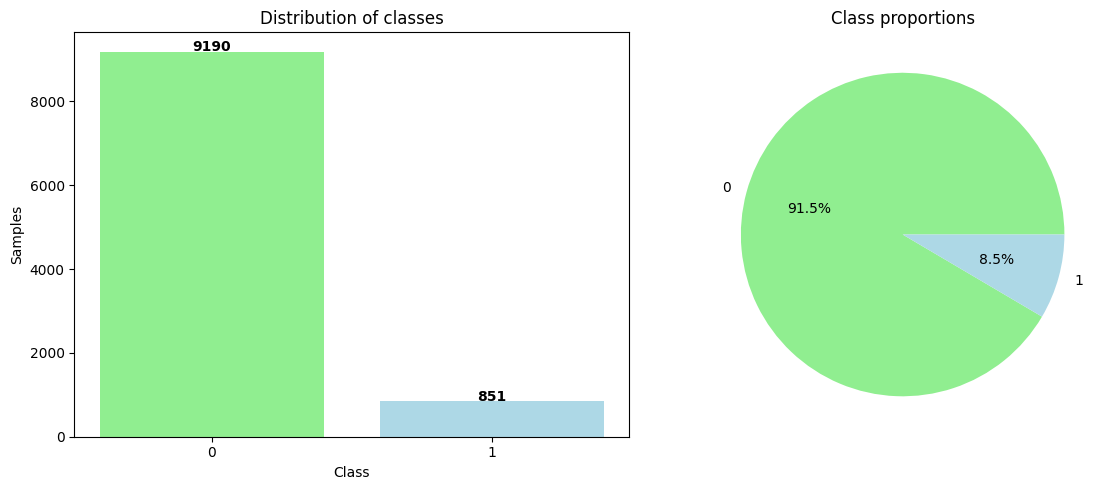

In [52]:
num_of_classes = train_dataframe[label_column].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(num_of_classes.index.astype(str), num_of_classes.values, color=["lightgreen", "lightblue"])
axes[0].set_title("Distribution of classes")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Samples")
for index_bar, value in enumerate(num_of_classes.values):
    axes[0].text(index_bar, value + 5, str(value), ha="center", fontweight="bold")

axes[1].pie(num_of_classes.values, labels=num_of_classes.index.astype(str),
            autopct="%1.1f%%", colors=["lightgreen", "lightblue"])
axes[1].set_title("Class proportions")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()


As we can see, the dataset is clearly unbalanced. Although it contains over **10,000 samples**, only **8.5% belong to the** `hateful` **class**. This may cause the model to prefer the `not_hateful` class, because predicting the majority class is simply more often correct. Therefore, we will need to handle this imbalance.

### Length of the input sentences


Length statistics
        char_length   word_length
count  10041.000000  10041.000000
mean      93.646649     12.372074
std       33.450993      4.721106
min        6.000000      1.000000
25%       67.000000      8.000000
50%       91.000000     12.000000
75%      120.000000     16.000000
max      214.000000     29.000000


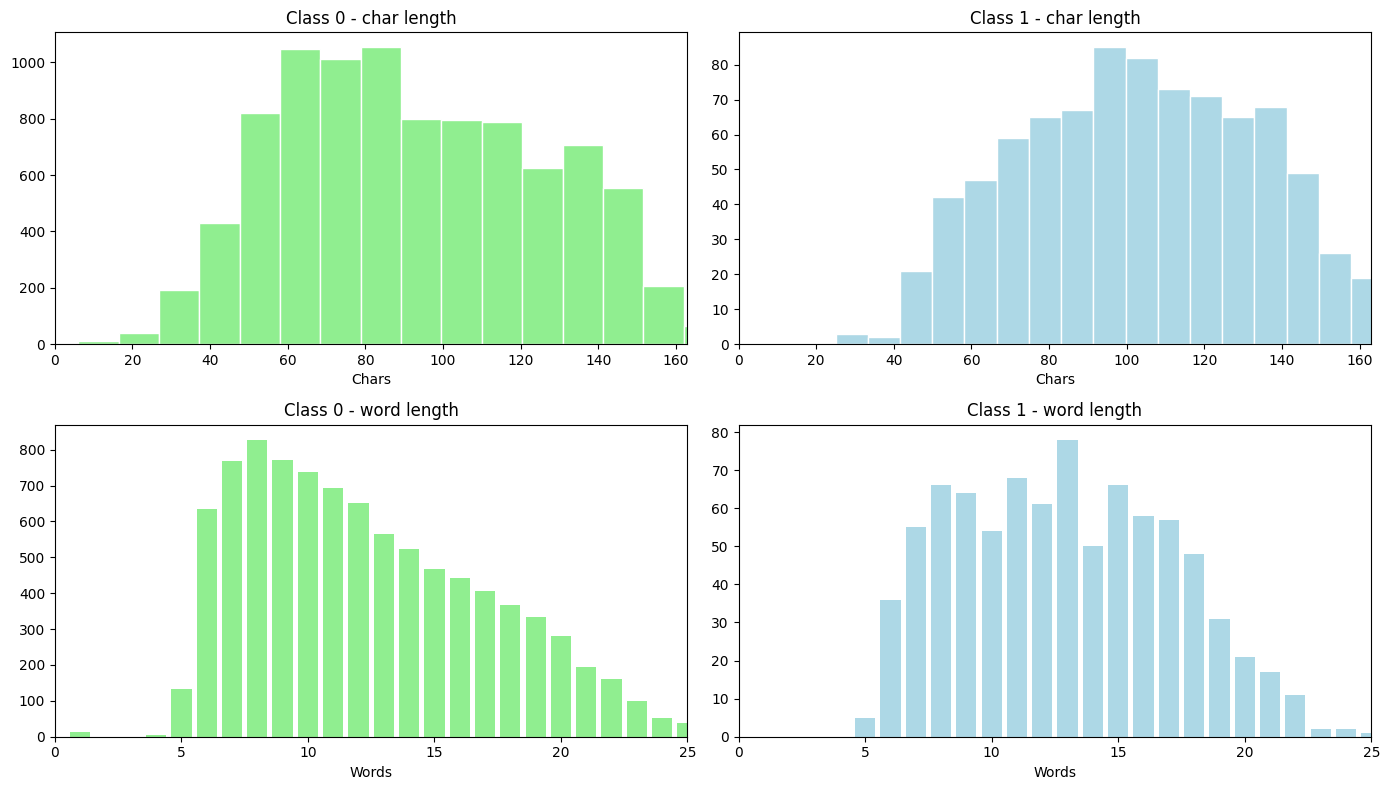

In [53]:


train_dataframe["char_length"] = train_dataframe[text_column].fillna("").astype(str).str.len()
train_dataframe["word_length"] = (
    train_dataframe[text_column].fillna("").astype(str).str.split().str.len()
)

print("\nLength statistics")
print(train_dataframe[["char_length", "word_length"]].describe())

classes = sorted(train_dataframe[label_column].unique())
colors = ["lightgreen", "lightblue"]

fig, axes = plt.subplots(2, len(classes), figsize=(14, 8))

max_char = int(train_dataframe["char_length"].quantile(0.99))
max_word = int(train_dataframe["word_length"].quantile(0.99))

for class_idx, class_value in enumerate(classes):
    subset = train_dataframe[train_dataframe[label_column] == class_value]

    axes[0, class_idx].hist(
        subset["char_length"],
        bins=20,
        color=colors[class_idx],
        edgecolor="white"
    )
    axes[0, class_idx].set_title(f"Class {class_value} - char length")
    axes[0, class_idx].set_xlabel("Chars")
    axes[0, class_idx].set_xlim(0, max_char)

    counts = subset["word_length"].value_counts().sort_index()
    axes[1, class_idx].bar(
        counts.index,
        counts.values,
        color=colors[class_idx],
        width=0.8
    )
    axes[1, class_idx].set_title(f"Class {class_value} - word length")
    axes[1, class_idx].set_xlabel("Words")
    axes[1, class_idx].set_xlim(0, max_word + 1)

plt.tight_layout()
plt.savefig("length_distributions.png", dpi=150)
plt.show()

Most samples are *short*, with **an average length of about 94 characters and 12 words** and the median is nearly identical. In practice, this means the model will probably focus on short, direct expressions and **may not need to handle long context** very often. It also suggests that choosing a reasonable maximum sequence length should be enough for most examples, without losing much information

In [54]:
for word_treshold in [5, 10, 15, 25, 50]:
    long_samples = (train_dataframe["word_length"] > word_treshold).mean() * 100
    print(f"\nSamples > {word_treshold} words: {long_samples:.1f}%")


Samples > 5 words: 98.5%

Samples > 10 words: 58.5%

Samples > 15 words: 26.4%

Samples > 25 words: 0.3%

Samples > 50 words: 0.0%


### Conclusion
As we can see, the dataset is clearly imbalanced, because the hateful class is much smaller than the not hateful class. We also see that most texts are short, so a reasonable input length should be enough for most samples.

Because of that the next experiments should check:
- the best pretrained model for Polish text,
- cased vs. uncased models,
- oversampling vs. class weights,
- limiting the input length